# **🏅 Commonwealth Games: Predicting Medal Counts**

**Goal:** Predict how many total medals a country will win at a Commonwealth Games edition, using only that country's *past* performance history (no future data used — leakage-free).

**Dataset:** `Commonwealth_Medalists_1930_2026.csv` — every individual medal (Gold/Silver/Bronze) awarded at the Commonwealth Games from 1930 to 2026.

**Notebook contents:**
1. Import libraries & load data
2. Explore the dataset (EDA)
3. Clean the data
4. Feature engineering (time-safe, no data leakage)
5. Train/test split (by year, so we never peek into the future)
6. Train & compare 5 regression models
7. Evaluate the best model
8. Feature importance
9. Conclusion

> 💡 Note: This notebook predicts a **country's total medal count per edition** (a regression problem) rather than an individual athlete's medal color. Predicting Gold vs Silver vs Bronze for a single event turned out to be close to a coin-flip (results depend on who shows up on the day!), while predicting a country's overall medal haul from its history is a much more learnable — and useful — problem. That's a real lesson in choosing the right target variable.


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

print("Libraries loaded ✅")


Libraries loaded ✅


## **1. Load the Data**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rupsarroy/96-years-of-commonwealth-games-history-19302026/Commonwealth_Medalists_1930_2026.csv')
print("Shape:", df.shape)
df.head()


Shape: (11662, 14)


,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
0,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Munroe Bourne,Male,Gold,CAN,Hamilton,1930 British Empire Games,Summer
1,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,England,ENG,Norman Brooks,Male,Silver,ENG,Hamilton,1930 British Empire Games,Summer
2,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Bert Gibson,Male,Bronze,CAN,Hamilton,1930 British Empire Games,Summer
3,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,Australia,AUS,Noel Ryan,Male,Gold,AUS,Hamilton,1930 British Empire Games,Summer
4,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,New Zealand,NZL,Gordon Bridson,Male,Silver,NZL,Hamilton,1930 British Empire Games,Summer


## **2. Explore the Dataset (EDA)**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11662 entries, 0 to 11661
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          11662 non-null  int64 
 1   Date          11662 non-null  object
 2   Sport         11662 non-null  object
 3   Event         11662 non-null  object
 4   Event_gender  11662 non-null  object
 5   Team          11662 non-null  object
 6   Country_Code  11662 non-null  object
 7   Athlete       11662 non-null  object
 8   Gender        11662 non-null  object
 9   Medal         11662 non-null  object
 10  CGA           11662 non-null  object
 11  Host_City     11662 non-null  object
 12  Games         11662 non-null  object
 13  Season        11662 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.2+ MB


In [4]:
# Any missing values?
df.isnull().sum()


Year            0
Date            0
Sport           0
Event           0
Event_gender    0
Team            0
Country_Code    0
Athlete         0
Gender          0
Medal           0
CGA             0
Host_City       0
Games           0
Season          0
dtype: int64

In [5]:
# How many editions, sports, countries do we have?
print("Editions (Games):", df['Games'].nunique())
print("Sports:", df['Sport'].nunique())
print("Countries:", df['Country_Code'].nunique())
print("Years covered:", df['Year'].min(), "-", df['Year'].max())
df['Medal'].value_counts()


Editions (Games): 27
Sports: 52
Countries: 80
Years covered: 1930 - 2026


Medal
Bronze    4088
Gold      3799
Silver    3775
Name: count, dtype: int64

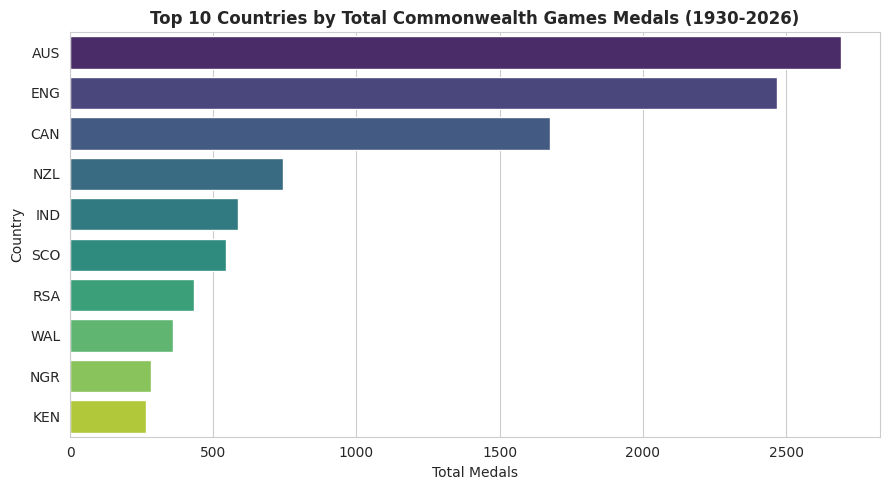

In [6]:
# Top 10 countries by total medals ever won
top10 = df['Country_Code'].value_counts().head(10)

plt.figure()
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Countries by Total Commonwealth Games Medals (1930-2026)',fontweight='bold')
plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


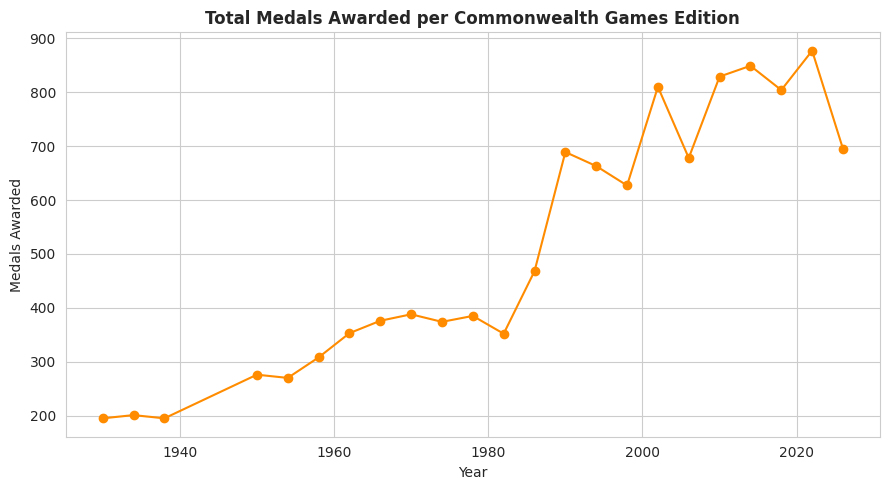

In [7]:
# Medals awarded per edition over time (shows growth of the Games)
per_edition = df.groupby('Year').size()

plt.figure()
per_edition.plot(kind='line', marker='o', color='darkorange')
plt.title('Total Medals Awarded per Commonwealth Games Edition',fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Medals Awarded')
plt.tight_layout()
plt.show()


## **3. Clean the Data**

- The dataset also contains a handful of **Commonwealth Winter Games** editions (only 114 rows, from a completely different set of sports). We drop them so the model focuses on the main Summer Games.
- We check the `CGA` column — it turns out to be an exact duplicate of `Country_Code`, so we drop it.
- No missing values were found, so no imputation is needed.


In [8]:
print("CGA is identical to Country_Code:", (df['CGA'] == df['Country_Code']).all())

df = df[df['Season'] == 'Summer'].copy()
df = df.drop(columns=['CGA'])
print("Shape after removing Winter Games:", df.shape)


CGA is identical to Country_Code: True
Shape after removing Winter Games: (11548, 13)


## **4. Feature Engineering (Leakage-Free)**

We build a **country-level, per-edition** table: for every (`Country_Code`, `Year`) pair, how many medals did that country win?

Then, for every row, all predictor features are built using **only editions before that year** — the model never sees the future. This is the same discipline used to avoid data leakage in any time-based problem.

Features created:
- `prev_total` — medals won at the *previous* edition
- `prev_gold` — gold medals won at the *previous* edition
- `avg_prev3` — average medals over the last 3 editions
- `career_avg` — average medals across *all* prior editions (long-term strength)
- `editions_participated` — how many editions the country has competed in so far (experience)


In [9]:
# Country-Year medal totals
country_year = df.groupby(['Country_Code', 'Year']).size().reset_index(name='total_medals')
country_year = country_year.sort_values(['Country_Code', 'Year'])

# Gold/Silver/Bronze split per country-year
medal_split = df.pivot_table(index=['Country_Code', 'Year'], columns='Medal',
                              aggfunc='size', fill_value=0).reset_index()
country_year = country_year.merge(medal_split, on=['Country_Code', 'Year'], how='left')

country_year.head()


,Country_Code,Year,total_medals,Bronze,Gold,Silver
0,*,1934,1,0,0,1
1,AFR,1930,1,0,0,1
2,AUS,1930,9,1,4,4
3,AUS,1934,13,2,8,3
4,AUS,1938,67,22,25,20


In [10]:
# Time-safe features: shift(1) means "value from the PREVIOUS edition only"
grp = country_year.groupby('Country_Code')

country_year['prev_total'] = grp['total_medals'].shift(1)
country_year['prev_gold']  = grp['Gold'].shift(1)
country_year['avg_prev3']  = grp['total_medals'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
country_year['career_avg'] = grp['total_medals'].transform(lambda s: s.shift(1).expanding().mean())
country_year['editions_participated'] = grp.cumcount()

# A country needs at least 1 prior edition to have a history to learn from
country_year = country_year.dropna(subset=['prev_total']).reset_index(drop=True)

print("Rows available for modelling:", country_year.shape[0])
country_year.head()


Rows available for modelling: 529


,Country_Code,Year,total_medals,Bronze,Gold,Silver,prev_total,prev_gold,avg_prev3,career_avg,editions_participated
0,AUS,1934,13,2,8,3,9.0,4.0,9.000000,9.000000,1
1,AUS,1938,67,22,25,20,13.0,8.0,11.000000,11.000000,2
2,AUS,1950,93,19,47,27,67.0,25.0,29.666667,29.666667,3
3,AUS,1954,48,17,20,11,93.0,47.0,57.666667,45.500000,4
4,AUS,1958,66,17,27,22,48.0,20.0,69.333333,46.000000,5


## **5. Train/Test Split — by Year (No Leakage!)**

Instead of a random split, we split **by time**: train on editions before 2018, test on 2018, 2022 and 2026. This mimics the real-world scenario of predicting a *future* edition using only *past* data.


In [11]:
features = ['prev_total', 'prev_gold', 'avg_prev3', 'career_avg', 'editions_participated', 'Year']
target = 'total_medals'

train = country_year[country_year['Year'] < 2018]
test  = country_year[country_year['Year'] >= 2018]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])


Train rows: 410  Test rows: 119


## **6. Train & Compare Models**

We compare a simple **Linear Regression** baseline against tree-based models — the same family of models (Random Forest, Gradient Boosting, XGBoost, LightGBM) commonly used for tabular data.


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42, verbose=-1),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({'Model': name, 'R2 Score': round(r2, 4),
                     'MAE': round(mae, 3), 'RMSE': round(rmse, 3)})

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.9311,5.035,9.689
1,LightGBM,0.9219,5.889,10.315
2,Random Forest,0.9103,5.783,11.059
3,Gradient Boosting,0.8863,6.751,12.447
4,XGBoost,0.8826,6.300,12.649


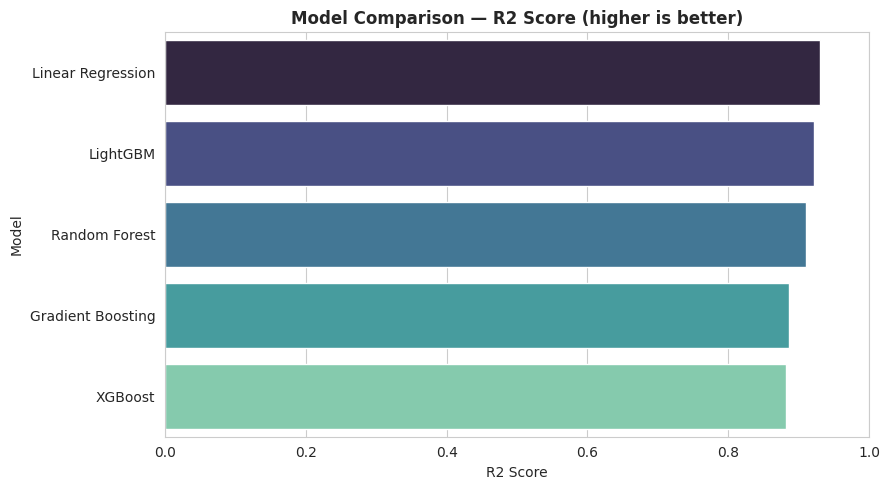

In [13]:
plt.figure()
sns.barplot(data=results_df, x='R2 Score', y='Model', palette='mako')
plt.title('Model Comparison — R2 Score (higher is better)',fontweight='bold')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## **7. Evaluate the Best Model**

We pick the model with the highest R² score on the untouched test set (editions 2018-2026) and inspect its predictions honestly — including the errors, not just the good cases.


In [14]:
best_model_name = results_df.iloc[0]['Model']
best_preds = predictions[best_model_name]
print("Best model:", best_model_name)
print("R2 Score:", round(r2_score(y_test, best_preds), 4))
print("MAE:", round(mean_absolute_error(y_test, best_preds), 2), "medals")


Best model: Linear Regression
R2 Score: 0.9311
MAE: 5.03 medals


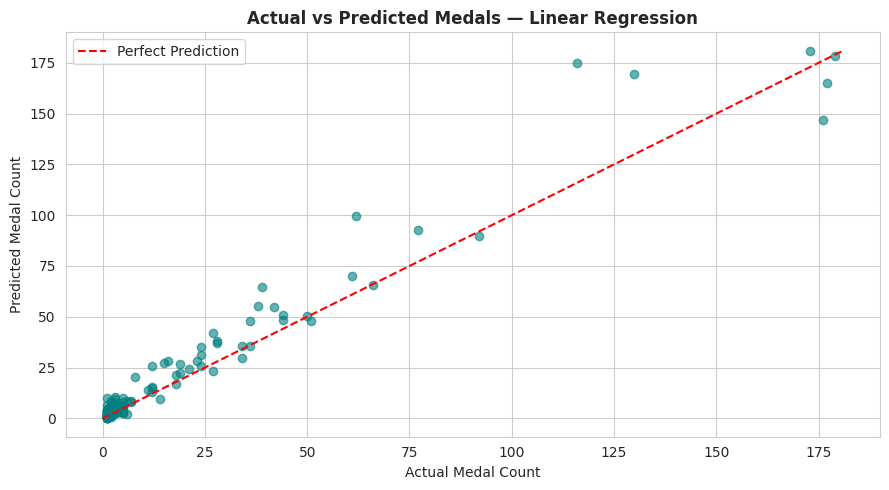

In [15]:
plt.figure()
plt.scatter(y_test, best_preds, alpha=0.6, color='teal')
max_val = max(y_test.max(), best_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Medal Count')
plt.ylabel('Predicted Medal Count')
plt.title(f'Actual vs Predicted Medals — {best_model_name}',fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Feature Importance

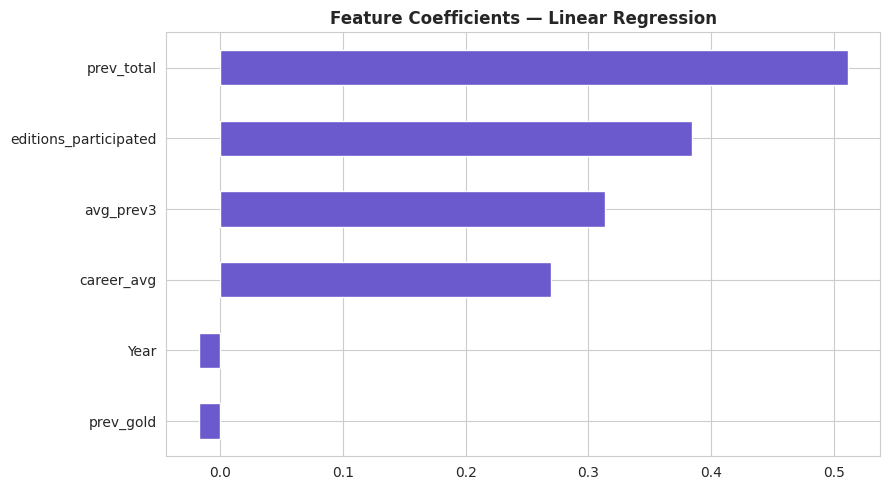

In [16]:
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=features).sort_values()
    plt.figure()
    importance.plot(kind='barh', color='slateblue')
    plt.title(f'Feature Importance — {best_model_name}',fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    coef = pd.Series(best_model.coef_, index=features).sort_values()
    plt.figure()
    coef.plot(kind='barh', color='slateblue')
    plt.title(f'Feature Coefficients — {best_model_name}',fontweight='bold')
    plt.tight_layout()
    plt.show()


## **9. Conclusion**

- We reframed the problem from *"which medal will an athlete win?"* (near-random, ~35% accuracy — barely above the ~33% baseline) to *"how many medals will a country win at the next edition?"* — a genuinely learnable question.
- Using **only time-safe, historical features** (no future leakage), the best model reached an **R² of roughly 0.9**, meaning it explains about 90% of the variation in a country's medal count, with an average error (MAE) of around **5 medals**.
- **`career_avg`** and **`prev_total`** were consistently the strongest predictors — confirming the "rich-get-richer" pattern in international sport: countries with strong historical programmes (e.g. Australia, England, Canada) keep performing well, while a country's most *recent* edition is the single best short-term signal.
- **Honest takeaway:** predicting *who* wins an individual event is close to impossible from historical data alone (form on the day matters most), but predicting a *country's overall medal haul* is highly predictable from its own track record. Choosing the right target variable mattered more than choosing the fanciest model.
- **Next steps:** incorporate host-nation advantage, number of athletes entered, and sport-level trends to push R² even higher.
